In [25]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import optuna
from src.features import cycle
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from src._lstm import LSTMRegressor, train_lstm_model
from src.visualization import plot_forecast
from sklearn.metrics import root_mean_squared_error

In [26]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df['is_anomaly'] = np.where(df['Дата'] <= '2021-05-17', 1, 0)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)

    return df

In [27]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [28]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

In [29]:
target_cols = ['48-1 (0)', '48-1 (1)', '48-1 (2)',
               '48-1 (3)', '48-1 (4)', '48-1 (5)', '48-1 (6)',
               '48-1 (7)', '48-1 (8)', '48-1 (9)', '48-1 (10)', '48-1 (11)']
features_cols = ['day_of_year', 'Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_anomaly']
lags_length = 14

df_train_full = df_train_full[features_cols + target_cols]
df_train = df_train[features_cols + target_cols]
df_val = df_val[features_cols + target_cols]
df_test = df_test[features_cols + target_cols]

In [30]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(df_train[features_cols])
train_target_scaled = target_scaler.fit_transform(df_train[target_cols])

train_scaled = np.hstack((train_features_scaled, train_target_scaled))

val_start = df_train[-lags_length:]
df_full_val = pd.concat([val_start, df_val])

val_features_scaled = feature_scaler.transform(df_full_val[features_cols])
val_target_scaled = target_scaler.transform(df_full_val[target_cols])

val_scaled = np.hstack((val_features_scaled, val_target_scaled))

full_train_features_scaled = feature_scaler.fit_transform(df_train_full[features_cols])
full_train_target_scaled = target_scaler.fit_transform(df_train_full[target_cols])

full_train_scaled = np.hstack((full_train_features_scaled, full_train_target_scaled))

In [31]:
def create_sequences(data, target_start_index, lags_length):
    X, y = [], []
    for i in range(len(data) - lags_length):
        X.append(data[i : i + lags_length])
        y.append(data[i + lags_length, target_start_index:])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

target_start_index = len(features_cols)

X_train, y_train = create_sequences(train_scaled, target_start_index, lags_length)
X_val, y_val = create_sequences(val_scaled, target_start_index, lags_length)
X_full_train, y_full_train = create_sequences(full_train_scaled, target_start_index, lags_length)

In [32]:
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
full_train_loader = DataLoader(TensorDataset(X_full_train, y_full_train), batch_size=batch_size)

In [33]:
input_size = train_scaled.shape[1]
output_size = len(target_cols)
criterion = nn.MSELoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def objective(trial):
    hidden_size = trial.suggest_int('hidden_size', 16, 128, step=16)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    
    model_trial = LSTMRegressor(input_size, hidden_size, num_layers, output_size=output_size).to(device)
    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=lr)

    model_trial, val_hist = train_lstm_model(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs=200,
        max_epochs_no_improvement=10,
        verbose=False
    )

    best_val_loss = min(val_hist)
    return best_val_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Лучшие параметры: ", study.best_params)

[I 2026-05-25 00:52:33,123] A new study created in memory with name: no-name-56952674-1c71-48c8-a365-912db35ce749
[I 2026-05-25 00:52:39,141] Trial 0 finished with value: 0.028793113692943517 and parameters: {'hidden_size': 32, 'num_layers': 2, 'lr': 0.006248845681644764}. Best is trial 0 with value: 0.028793113692943517.


Early stopping on 48 epoch


[I 2026-05-25 00:52:43,588] Trial 1 finished with value: 0.027580790496507628 and parameters: {'hidden_size': 96, 'num_layers': 2, 'lr': 0.0002492676452552952}. Best is trial 1 with value: 0.027580790496507628.


Early stopping on 36 epoch


[I 2026-05-25 00:52:56,798] Trial 2 finished with value: 0.006825990175899586 and parameters: {'hidden_size': 128, 'num_layers': 1, 'lr': 0.0005486272894254226}. Best is trial 2 with value: 0.006825990175899586.


...

Early stopping on 97 epoch


[I 2026-05-25 00:53:57,442] Trial 6 finished with value: 0.04535050645389192 and parameters: {'hidden_size': 32, 'num_layers': 3, 'lr': 3.278278455463064e-05}. Best is trial 2 with value: 0.006825990175899586.
[I 2026-05-25 00:54:24,225] Trial 7 finished with value: 0.03512406400074073 and parameters: {'hidden_size': 48, 'num_layers': 3, 'lr': 4.099097885773301e-05}. Best is trial 2 with value: 0.006825990175899586.
[I 2026-05-25 00:54:27,587] Trial 8 finished with value: 0.03492678635718067 and parameters: {'hidden_size': 96, 'num_layers': 3, 'lr': 0.0002103325789190482}. Best is trial 2 with value: 0.006825990175899586.


Early stopping on 22 epoch


[I 2026-05-25 00:54:39,741] Trial 9 finished with value: 0.008193118983747366 and parameters: {'hidden_size': 96, 'num_layers': 1, 'lr': 0.0009406747309811294}. Best is trial 2 with value: 0.006825990175899586.


Early stopping on 107 epoch
Лучшие параметры:  {'hidden_size': 128, 'num_layers': 1, 'lr': 0.0005486272894254226}


In [34]:
# input_size = full_train_scaled.shape[1]
model = LSTMRegressor(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    output_size=output_size
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=study.best_params['lr'])

model, _ = train_lstm_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=200,
    max_epochs_no_improvement=10,
    verbose=True
)

Epoch 1/200, Train Loss: 0.7677, Val Loss: 0.2753
Epoch 2/200, Train Loss: 0.2341, Val Loss: 0.1159
Epoch 3/200, Train Loss: 0.1062, Val Loss: 0.0673
Epoch 4/200, Train Loss: 0.0604, Val Loss: 0.0441
Epoch 5/200, Train Loss: 0.0383, Val Loss: 0.0378
Epoch 6/200, Train Loss: 0.0288, Val Loss: 0.0331
Epoch 7/200, Train Loss: 0.0235, Val Loss: 0.0320
Epoch 8/200, Train Loss: 0.0197, Val Loss: 0.0281
Epoch 9/200, Train Loss: 0.0175, Val Loss: 0.0416
Epoch 10/200, Train Loss: 0.0433, Val Loss: 0.0522
Epoch 11/200, Train Loss: 0.0313, Val Loss: 0.0351
Epoch 12/200, Train Loss: 0.0163, Val Loss: 0.0271
Epoch 13/200, Train Loss: 0.0153, Val Loss: 0.0272
Epoch 14/200, Train Loss: 0.0105, Val Loss: 0.0272
Epoch 15/200, Train Loss: 0.0100, Val Loss: 0.0262
Epoch 16/200, Train Loss: 0.0118, Val Loss: 0.0255
Epoch 17/200, Train Loss: 0.0098, Val Loss: 0.0252
Epoch 18/200, Train Loss: 0.0108, Val Loss: 0.0247
Epoch 19/200, Train Loss: 0.0094, Val Loss: 0.0240
Epoch 20/200, Train Loss: 0.0110, Val Lo

Test RMSE: 0.6819
RMSE for 48-1 (0): 3.0467


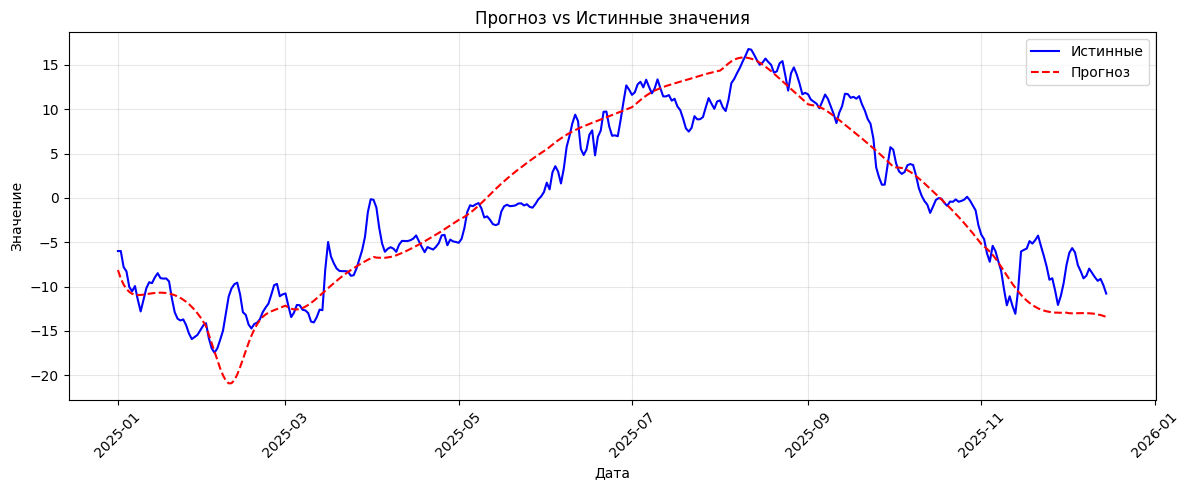

RMSE for 48-1 (1): 1.1159


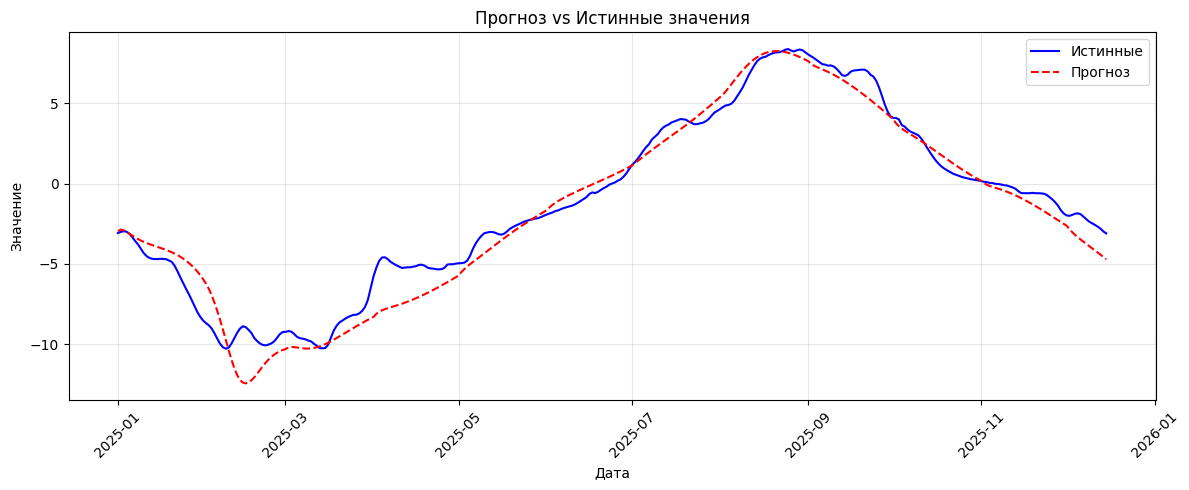

RMSE for 48-1 (2): 0.7817


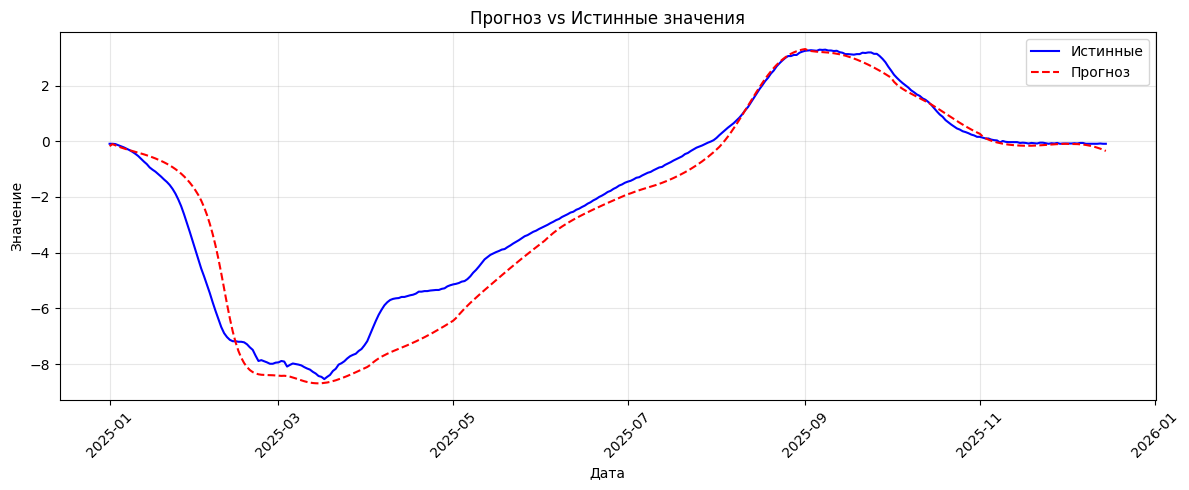

RMSE for 48-1 (3): 0.6491


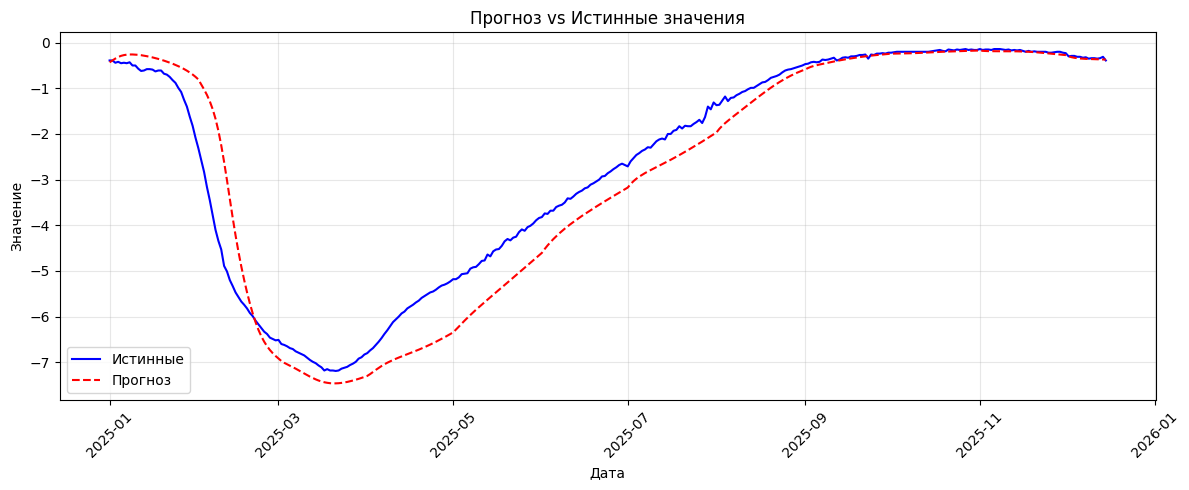

RMSE for 48-1 (4): 0.4786


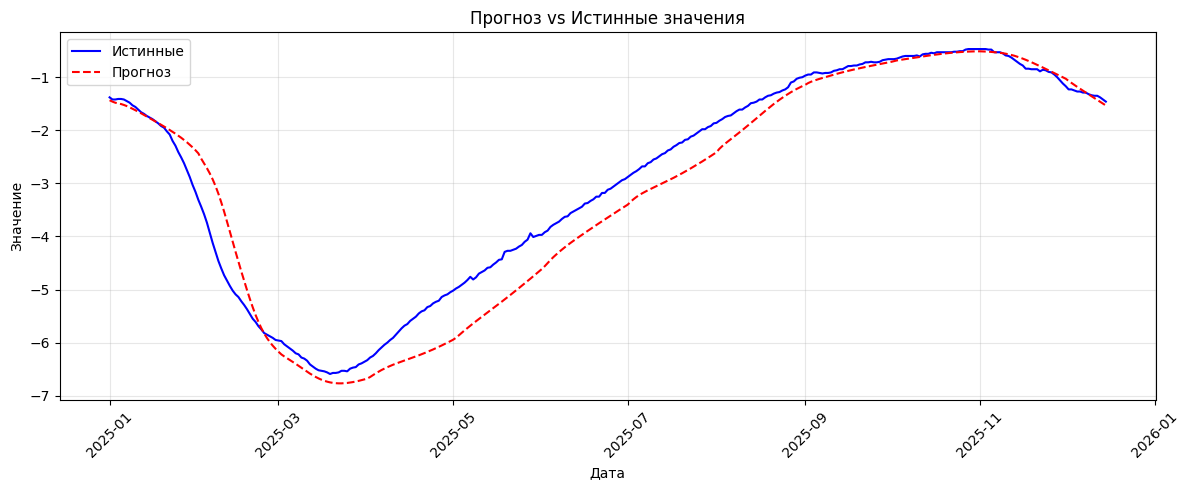

RMSE for 48-1 (5): 0.4221


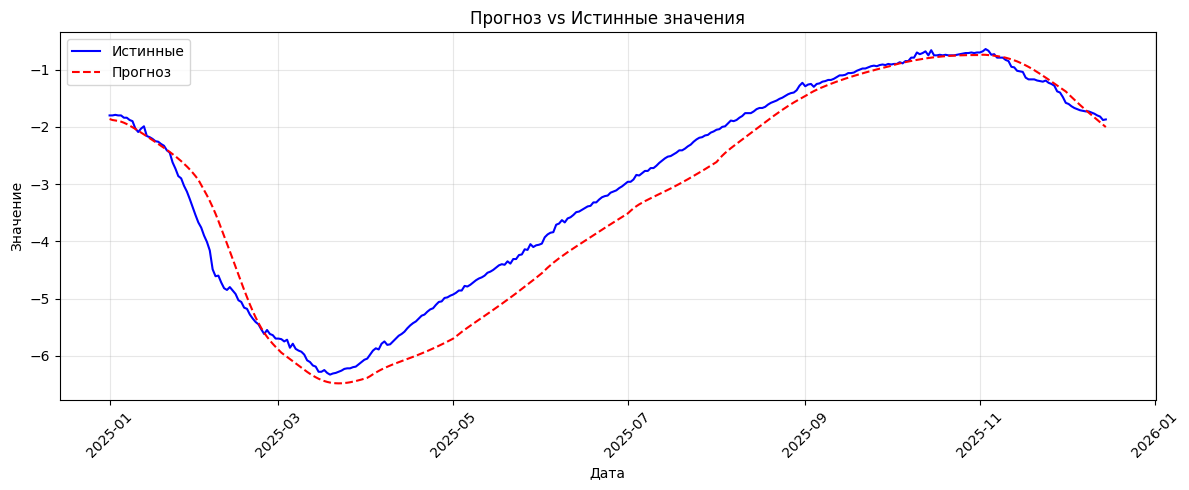

RMSE for 48-1 (6): 0.4070


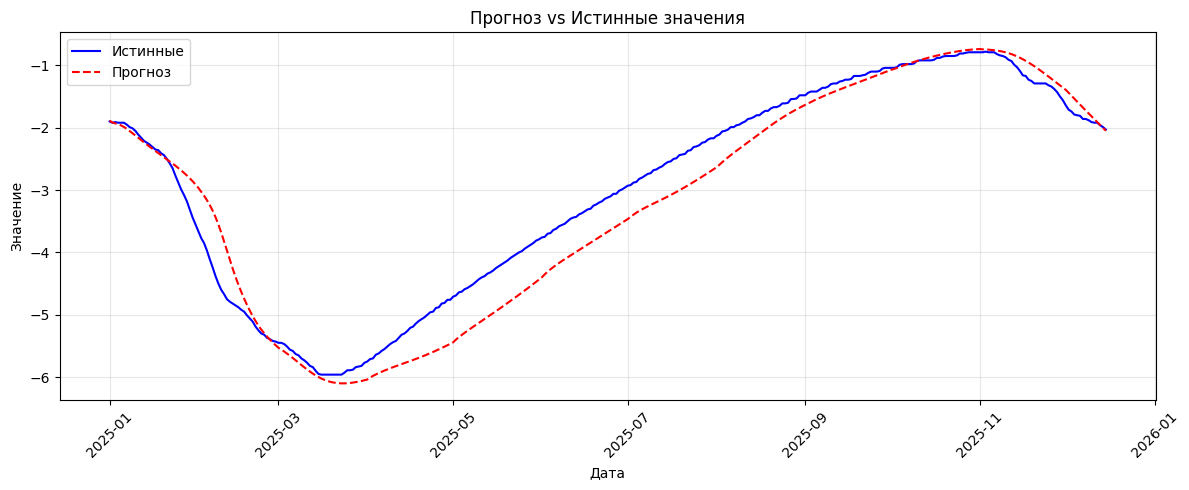

RMSE for 48-1 (7): 0.3516


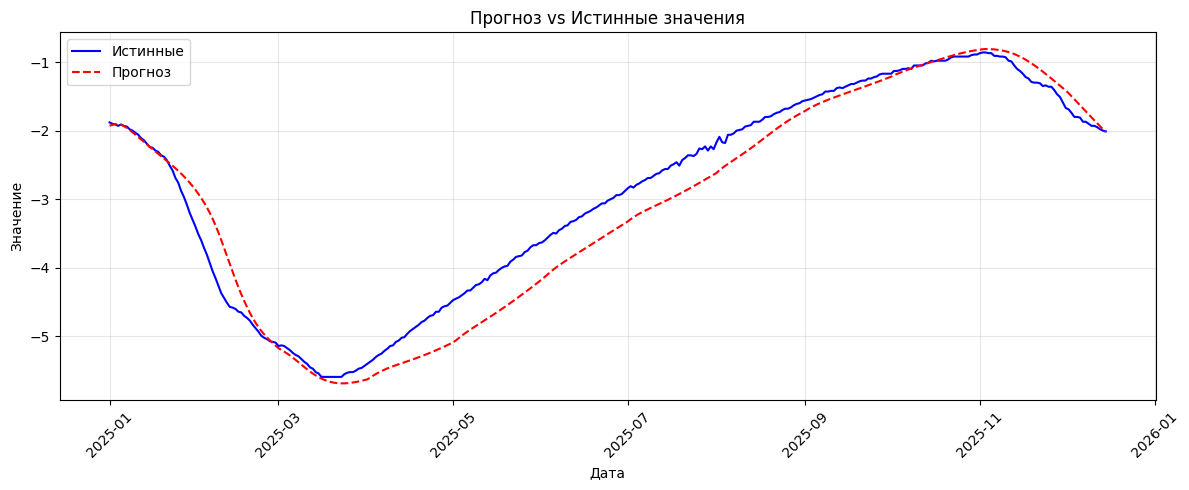

RMSE for 48-1 (8): 0.3187


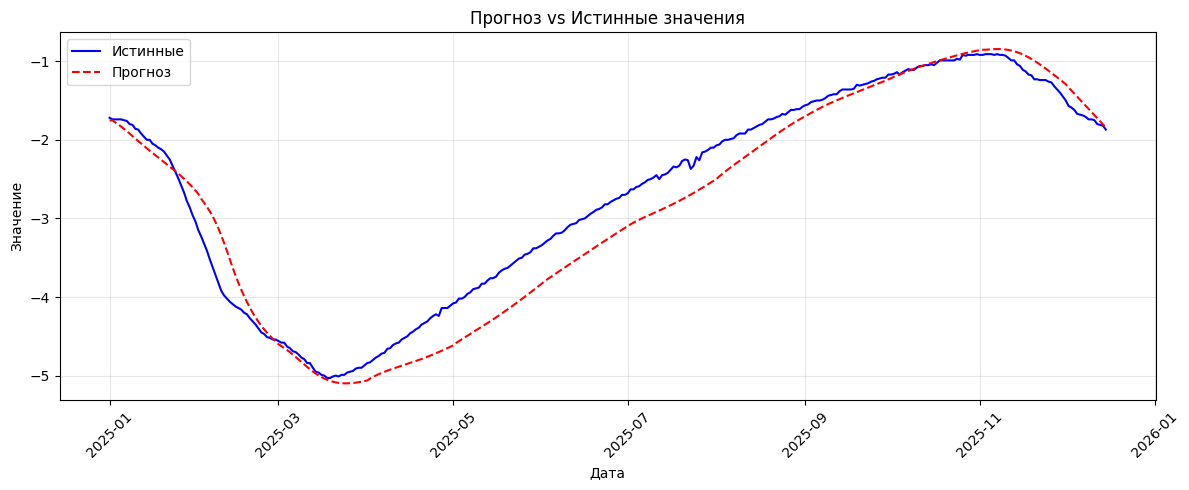

RMSE for 48-1 (9): 0.2631


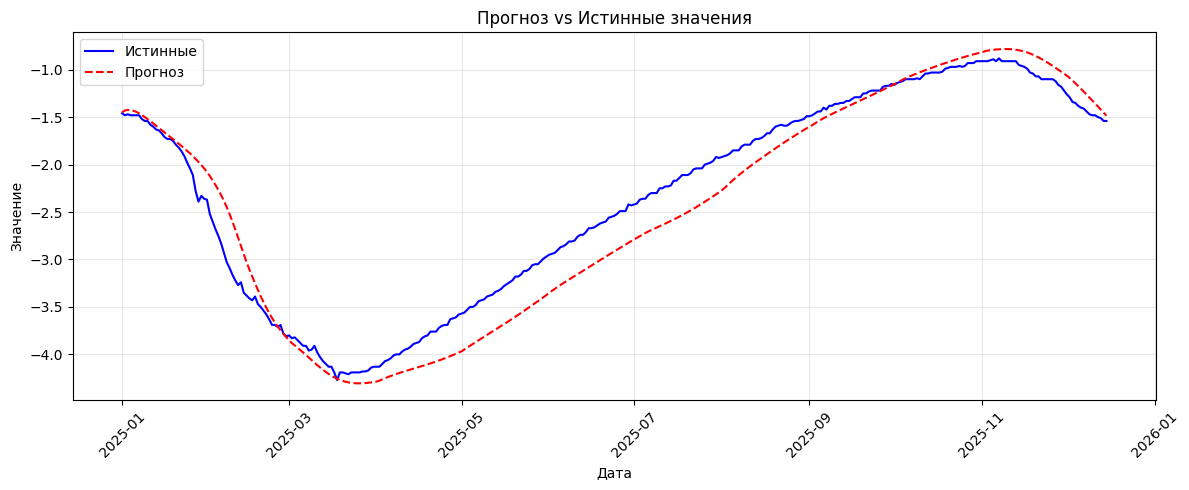

RMSE for 48-1 (10): 0.1981


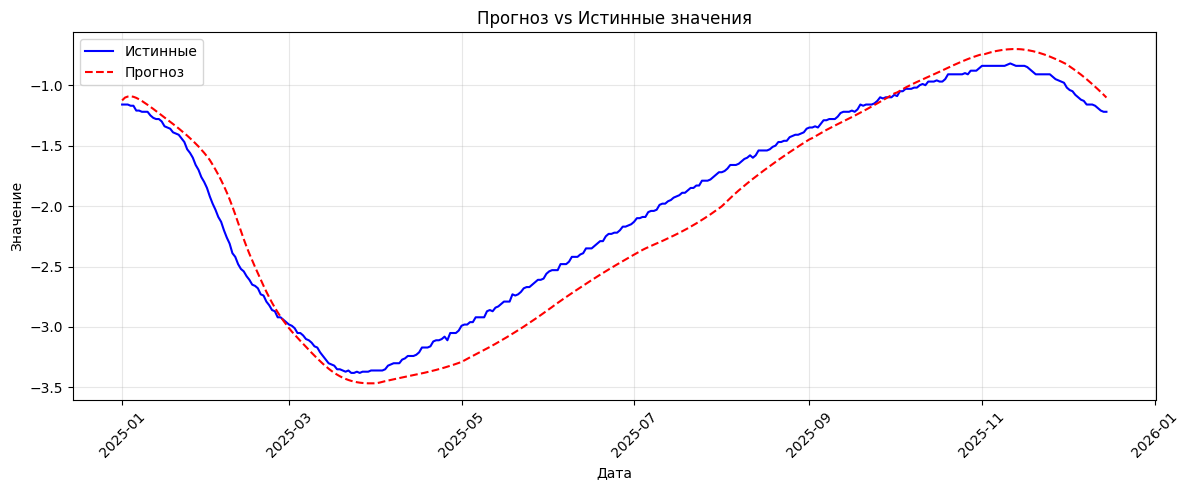

RMSE for 48-1 (11): 0.1498


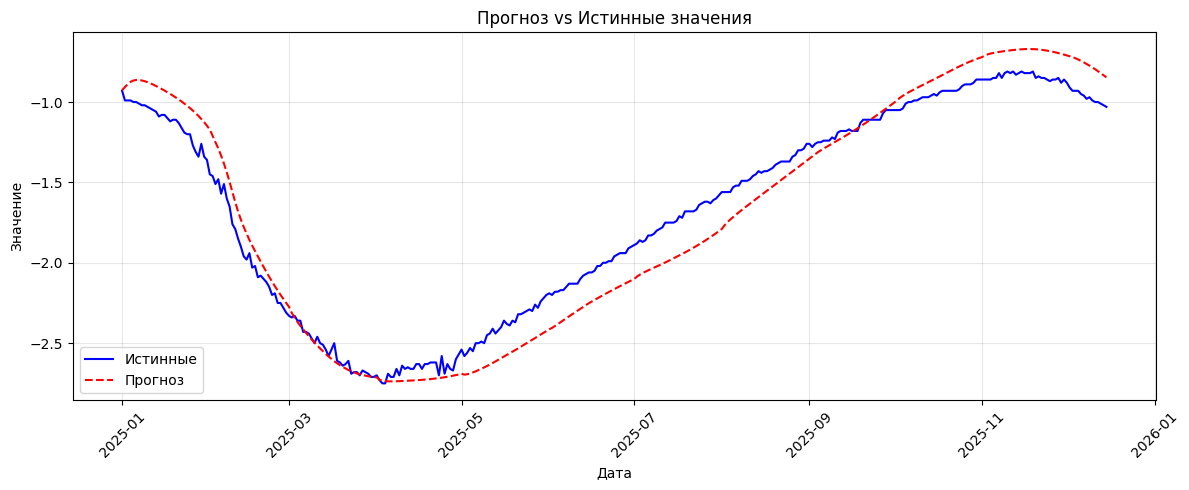

In [ ]:
test_start = df_train_full[-lags_length:]

start_features_scaled = feature_scaler.transform(test_start[features_cols])
start_target_scaled = target_scaler.transform(test_start[target_cols])

current_lags = np.hstack((start_features_scaled, start_target_scaled))

future_features_scaled = feature_scaler.transform(df_test[features_cols])

model.eval()
y_pred_scaled = []

with torch.no_grad():
    for i in range(len(df_test)):
        lags_tensor = torch.tensor(current_lags, dtype=torch.float32).unsqueeze(0).to(device)

        pred = model(lags_tensor).cpu().numpy()[0]
        y_pred_scaled.append(pred)

        next_step_features = future_features_scaled[i]

        next_step_vector = np.append(next_step_features, pred)

        current_lags = np.vstack((current_lags[1:], next_step_vector))

y_pred_scaled = np.array(y_pred_scaled)

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = df_test[target_cols].values

rmse = root_mean_squared_error(y_true, y_pred)
print(f"Test RMSE: {rmse:.4f}")

rmse_per_depth = root_mean_squared_error(y_true, y_pred, multioutput='raw_values')
for i, col in enumerate(target_cols):
    rmse = rmse_per_depth[i]
    print(f'RMSE for {col}: {rmse:.4f}')
    
    s_true = pd.Series(y_true[:, i], index=df_test.index)
    s_pred = pd.Series(y_pred[:, i], index=df_test.index)
    
    plot_forecast(pd.DataFrame(s_true), pd.DataFrame(s_pred))